In [2]:
import h5py
import numpy as np
import sys

# import torch
# import tqdm 
# import pandas as pd
# import math

import functools as ft
from sklearn.metrics import roc_curve, auc, plot_roc_curve

In [3]:
# g(f(x)) -> F([x, f, g, ...])
F = lambda z: [*ft.reduce(lambda x, y: map(y, x), [z[:1]] + z[1:])][0]

def permutation(*data):
    perm = F([data[0].shape[0], range, np.random.permutation])
    return [x[perm] for x in data]


h5_name = '4tops_fcn_splitted.h5'

hf = h5py.File(h5_name, 'r')
print(hf.keys())

reg_train = np.array(hf.get("X_train")).astype("float32")#[:1280]
sig_train_label = np.array(hf.get("Y_train")).astype("int8")#[:1280]

print("sig_train_label", sig_train_label)
sig_train = np.where(sig_train_label > 1, 0, sig_train_label)
print("sig_train", sig_train)


reg_train, sig_train = permutation(reg_train, sig_train)


reg_val = np.array(hf.get("X_val")).astype("float32")#[:1280]
sig_val_label = np.array(hf.get("y_val")).astype("int8")#[:1280]

print("sig_val_label", sig_val_label)
sig_val = np.where(sig_val_label > 1, 0, sig_val_label)
print("sig_val", sig_val)


reg_val, sig_val = permutation(reg_val, sig_val)


reg_test = np.array(hf.get("X_test")).astype("float32")#[:1280]
sig_test_label = np.array(hf.get("y_test")).astype("int8")#[:1280]

print("sig_test_label", sig_test_label)
sig_test = np.where(sig_test_label > 1, 0, sig_test_label)
print("sig_test", sig_test)

# reg_test, sig_test = permutation(reg_test, sig_test)

# print(reg_train.shape)
# print(sig_train.shape)
# print(reg_val.shape)
# print(sig_val.shape)
# print(reg_test.shape)
# print(sig_test.shape)

print("reg_train shape", reg_train.shape)
print("reg_train\n", reg_train)

print("sig_train shape", sig_train.shape)
print("sig_train\n", sig_train)

print("reg_val shape", reg_val.shape)
print("reg_val\n", reg_val)

print("sig_val shape", sig_val.shape)
print("sig_val\n", sig_val)

print("reg_test shape", reg_test.shape)
print("reg_test\n", reg_test)

print("sig_test shape", sig_test.shape)
print("sig_test\n", sig_test)


################## useful for plotting, labels per process #####################
# print("sig_train_label shape", sig_train_label.shape)
# print("sig_train_label\n", sig_train_label)

# print("sig_val_label shape", sig_val_label.shape)
# print("sig_val_label\n", sig_val_label)

# print("sig_test_label shape", sig_test_label.shape)
# print("sig_test_label\n", sig_test_label)
#################################################################################


# if you want to save a new .h5 file with labels 0,1 

# ##################### to save the numpy arrays to h5 ###############################

# h5_name = 'data/4tops_fcn_splitted_BC.h5'

# hf = h5py.File(h5_name, 'w')

# hf.create_dataset('reg_train', data=reg_train)
# hf.create_dataset('sig_train', data=sig_train)

# hf.create_dataset('reg_val', data=reg_val)
# hf.create_dataset('sig_val', data=sig_val)

# hf.create_dataset('reg_test', data=reg_test)
# hf.create_dataset('sig_test', data=sig_test)


# hf.create_dataset('sig_train_label', data=sig_train_label)
# hf.create_dataset('sig_val_label', data=sig_val_label)
# hf.create_dataset('sig_test_label', data=sig_test_label)


# hf.close()
# ####################################################################################








<KeysViewHDF5 ['X_test', 'X_train', 'X_val', 'Y_train', 'y_test', 'y_val']>
sig_train_label [4 2 1 ... 1 3 3]
sig_train [0 0 1 ... 1 0 0]
sig_val_label [5 2 1 ... 1 2 5]
sig_val [0 0 1 ... 1 0 0]
sig_test_label [4 3 1 ... 1 1 1]
sig_test [0 0 1 ... 1 1 1]
reg_train shape (241658, 56)
reg_train
 [[ 6.         2.         1.        ... 11.029731  -0.628629   0.0996151]
 [ 5.         2.         1.        ... 10.48682   -0.811486  -1.6463   ]
 [ 4.         4.         0.        ...  0.         0.         0.       ]
 ...
 [ 4.         2.         0.        ... 10.745897  -0.2615    -2.44077  ]
 [ 4.         2.         0.        ... 10.825949  -1.81514   -1.88468  ]
 [ 5.         2.         0.        ...  0.         0.         0.       ]]
sig_train shape (241658,)
sig_train
 [0 1 0 ... 0 0 0]
reg_val shape (30207, 56)
reg_val
 [[ 5.        3.        1.       ... 11.490453 -0.556747  2.86973 ]
 [ 5.        2.        0.       ...  0.        0.        0.      ]
 [ 5.        3.        1.       ... 

In [4]:
# Renaming the datasets to make a bit more sense to me.
X_train, Y_train= reg_train, sig_train
X_val, Y_val = reg_val, sig_val
X_test, Y_test = reg_test, sig_test

# Compute the mean and standard deviation of the training set
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# Normalize the training set
X_train = (X_train - mean) / std

# Normalize the validation set and test set using the same mean and std as the training set
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the model architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(56, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Instantiate the model
model = Net()

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Convert numpy arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.int64)
X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.int64)
X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.int64)

# Train the model
for epoch in range(10):
    running_loss = 0.0
    for i in range(len(X_train)):
        inputs = X_train[i]
        labels = Y_train[i]
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs.unsqueeze(0), labels.unsqueeze(0))

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:    # Print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

# Test the model
correct = 0
total = 0
with torch.no_grad():
    for i in range(len(X_test)):
        inputs = X_test[i]
        labels = Y_test[i]
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 0)
        total += 1
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the test data: %d %%' % (
    100 * correct / total))


[1,  2000] loss: 0.631
[1,  4000] loss: 0.604
[1,  6000] loss: 0.597
[1,  8000] loss: 0.621
[1, 10000] loss: 0.618
[1, 12000] loss: 0.598
[1, 14000] loss: 0.618
[1, 16000] loss: 0.606
[1, 18000] loss: 0.608
[1, 20000] loss: 0.596
[1, 22000] loss: 0.607
[1, 24000] loss: 0.613
[1, 26000] loss: 0.609
[1, 28000] loss: 0.611
[1, 30000] loss: 0.606
[1, 32000] loss: 0.595
[1, 34000] loss: 0.586
[1, 36000] loss: 0.597
[1, 38000] loss: 0.604
[1, 40000] loss: 0.603
[1, 42000] loss: 0.595
[1, 44000] loss: 0.596
[1, 46000] loss: 0.587
[1, 48000] loss: 0.604
[1, 50000] loss: 0.592
[1, 52000] loss: 0.583
[1, 54000] loss: 0.605
[1, 56000] loss: 0.594
[1, 58000] loss: 0.592
[1, 60000] loss: 0.613
[1, 62000] loss: 0.601
[1, 64000] loss: 0.601
[1, 66000] loss: 0.599
[1, 68000] loss: 0.576
[1, 70000] loss: 0.603
[1, 72000] loss: 0.599
[1, 74000] loss: 0.578
[1, 76000] loss: 0.607
[1, 78000] loss: 0.592
[1, 80000] loss: 0.589
[1, 82000] loss: 0.590
[1, 84000] loss: 0.594
[1, 86000] loss: 0.604
[1, 88000] 

[3, 218000] loss: 0.596
[3, 220000] loss: 0.587
[3, 222000] loss: 0.596
[3, 224000] loss: 0.601
[3, 226000] loss: 0.606
[3, 228000] loss: 0.594
[3, 230000] loss: 0.581
[3, 232000] loss: 0.588
[3, 234000] loss: 0.603
[3, 236000] loss: 0.590
[3, 238000] loss: 0.593
[3, 240000] loss: 0.594
[4,  2000] loss: 0.605
[4,  4000] loss: 0.593
[4,  6000] loss: 0.576
[4,  8000] loss: 0.609
[4, 10000] loss: 0.602
[4, 12000] loss: 0.585
[4, 14000] loss: 0.608
[4, 16000] loss: 0.603
[4, 18000] loss: 0.595
[4, 20000] loss: 0.582
[4, 22000] loss: 0.599
[4, 24000] loss: 0.602
[4, 26000] loss: 0.598
[4, 28000] loss: 0.601
[4, 30000] loss: 0.598
[4, 32000] loss: 0.585
[4, 34000] loss: 0.577
[4, 36000] loss: 0.587
[4, 38000] loss: 0.596
[4, 40000] loss: 0.583
[4, 42000] loss: 0.599
[4, 44000] loss: 0.601
[4, 46000] loss: 0.582
[4, 48000] loss: 0.601
[4, 50000] loss: 0.587
[4, 52000] loss: 0.579
[4, 54000] loss: 0.601
[4, 56000] loss: 0.595
[4, 58000] loss: 0.583
[4, 60000] loss: 0.601
[4, 62000] loss: 0.596

[6, 194000] loss: 0.692
[6, 196000] loss: 0.693
[6, 198000] loss: 0.694
[6, 200000] loss: 0.695
[6, 202000] loss: 0.695
[6, 204000] loss: 0.695
[6, 206000] loss: 0.695
[6, 208000] loss: 0.694
[6, 210000] loss: 0.695
[6, 212000] loss: 0.695
[6, 214000] loss: 0.694
[6, 216000] loss: 0.695
[6, 218000] loss: 0.694
[6, 220000] loss: 0.695
[6, 222000] loss: 0.695
[6, 224000] loss: 0.695
[6, 226000] loss: 0.695
[6, 228000] loss: 0.694
[6, 230000] loss: 0.695
[6, 232000] loss: 0.695
[6, 234000] loss: 0.694
[6, 236000] loss: 0.694
[6, 238000] loss: 0.695
[6, 240000] loss: 0.695
[7,  2000] loss: 0.694
[7,  4000] loss: 0.695
[7,  6000] loss: 0.693
[7,  8000] loss: 0.694
[7, 10000] loss: 0.693
[7, 12000] loss: 0.695
[7, 14000] loss: 0.695
[7, 16000] loss: 0.694
[7, 18000] loss: 0.695
[7, 20000] loss: 0.694
[7, 22000] loss: 0.695
[7, 24000] loss: 0.694
[7, 26000] loss: 0.694
[7, 28000] loss: 0.694
[7, 30000] loss: 0.695
[7, 32000] loss: 0.694
[7, 34000] loss: 0.695
[7, 36000] loss: 0.695
[7, 38000]

KeyboardInterrupt: 

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import numpy as np

# Define the model architecture
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(56, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Define the dataset and dataloaders
train_dataset = TensorDataset(torch.Tensor(X_train), torch.Tensor(Y_train))
val_dataset = TensorDataset(torch.Tensor(X_val), torch.Tensor(Y_val))
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# Define the model, loss function, and optimizer
model = MyModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model with early stopping
best_val_loss = np.inf
patience = 10
counter = 0

for epoch in range(100):
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    val_preds = []
    val_labels = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels.long())
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, axis=1)
            val_preds += preds.cpu().numpy().tolist()
            val_labels += labels.cpu().numpy().tolist()
        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)

    print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    # Check if the validation loss has improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pt')  # save the model weights
    else:
        counter += 1
        if counter >= patience:
            print(f'Validation loss did not improve for {patience} epochs. Stopping early.')
            break
            
print('Finished Training')

# Save & Load the best model
torch.save(model.state_dict(), 'FCC_001.pt')
model.load_state_dict(torch.load('best_model.pt'))



Epoch 1: Train Loss: 0.5363, Val Loss: 0.5185, Val Acc: 0.7454
Epoch 2: Train Loss: 0.5260, Val Loss: 0.5161, Val Acc: 0.7463
Epoch 3: Train Loss: 0.5222, Val Loss: 0.5108, Val Acc: 0.7482
Epoch 4: Train Loss: 0.5198, Val Loss: 0.5099, Val Acc: 0.7496
Epoch 5: Train Loss: 0.5175, Val Loss: 0.5081, Val Acc: 0.7526
Epoch 6: Train Loss: 0.5160, Val Loss: 0.5107, Val Acc: 0.7502
Epoch 7: Train Loss: 0.5147, Val Loss: 0.5073, Val Acc: 0.7511
Epoch 8: Train Loss: 0.5142, Val Loss: 0.5085, Val Acc: 0.7515
Epoch 9: Train Loss: 0.5138, Val Loss: 0.5077, Val Acc: 0.7521
Epoch 10: Train Loss: 0.5133, Val Loss: 0.5069, Val Acc: 0.7527
Epoch 11: Train Loss: 0.5130, Val Loss: 0.5068, Val Acc: 0.7519
Epoch 12: Train Loss: 0.5125, Val Loss: 0.5070, Val Acc: 0.7515
Epoch 13: Train Loss: 0.5121, Val Loss: 0.5076, Val Acc: 0.7514
Epoch 14: Train Loss: 0.5119, Val Loss: 0.5067, Val Acc: 0.7523
Epoch 15: Train Loss: 0.5115, Val Loss: 0.5066, Val Acc: 0.7506
Epoch 16: Train Loss: 0.5114, Val Loss: 0.5066, V

<All keys matched successfully>

In [7]:
"""
# Test the model
correct = 0
total = 0
with torch.no_grad():
    for i in range(len(X_test)):
        inputs = X_test[i]
        labels = Y_test[i]
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 0)
        total += 1
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the test data: %d %%' % (
    100 * correct / total))

"""

# Test the model
correct = 0
total = 0

X_train = torch.Tensor(X_train)
X_test = torch.Tensor(X_test)

with torch.no_grad():
    for i in range(len(X_test)):
        inputs = X_train[i]
        labels = Y_test[i]
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 0)
        total += 1
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the test data: %d %%' % (
    100 * correct / total))

Accuracy of the network on the test data: 50 %


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, plot_roc_curve

# assume your PyTorch model is called 'model', and your test set inputs are called 'X_test'
# get the predicted probabilities for the test set
model.eval()
with torch.no_grad():
    y_pred_proba = model(torch.Tensor(X_test))
    
# convert the predicted probabilities to binary predictions
y_pred = np.where(y_pred_proba > 0.5, 1, 0)

# calculate the false positive rate, true positive rate, and threshold values for the ROC curve
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba)

# calculate the area under the ROC curve
roc_auc = auc(fpr, tpr)

# plot the ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()


ValueError: y should be a 1d array, got an array of shape (30207, 2) instead.

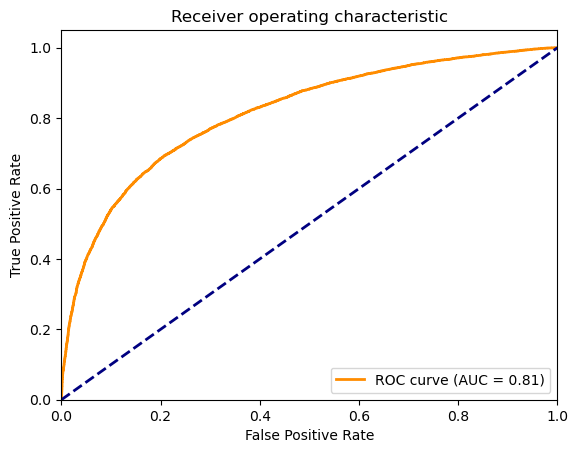

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# load the saved PyTorch model
model = MyModel()
model.load_state_dict(torch.load('FCC_001.pt'))

# set the model to evaluation mode
model.eval()

# make predictions on the test set
with torch.no_grad():
    y_pred = model(X_test)
    y_scores = torch.softmax(y_pred, dim=1)[:, 1].cpu().numpy()
    y_true = Y_test.cpu().numpy()

# calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()
